# 01 - Exploratory Data Analysis

Load the combined Airbnb dataset and inspect the basic structure.

In [82]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#Load the data
df = pd.read_csv('../data/processed/airbnb_combined.csv')

In [83]:
#Overview of the dataset
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51707 entries, 0 to 51706
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city                        51707 non-null  object 
 1   day_type                    51707 non-null  object 
 2   Unnamed: 0                  51707 non-null  int64  
 3   realSum                     51707 non-null  float64
 4   room_type                   51707 non-null  object 
 5   room_shared                 51707 non-null  bool   
 6   room_private                51707 non-null  bool   
 7   person_capacity             51707 non-null  float64
 8   host_is_superhost           51707 non-null  bool   
 9   multi                       51707 non-null  int64  
 10  biz                         51707 non-null  int64  
 11  cleanliness_rating          51707 non-null  float64
 12  guest_satisfaction_overall  51707 non-null  float64
 13  bedrooms                    517

,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
count,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.00000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000,51707.000000
mean,1620.502388,279.879591,3.161661,0.291353,0.350204,9.390624,92.628232,1.15876,3.191285,0.681540,294.204105,13.423792,626.856696,22.786177,7.426068,45.671128
std,1217.380366,327.948386,1.298545,0.454390,0.477038,0.954868,8.945531,0.62741,2.393803,0.858023,224.754123,9.807985,497.920226,17.804096,9.799725,5.249263
min,0.000000,34.779339,2.000000,0.000000,0.000000,2.000000,20.000000,0.00000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757,-9.226340,37.953000
25%,646.000000,148.752174,2.000000,0.000000,0.000000,9.000000,90.000000,1.00000,1.453142,0.248480,136.797385,6.380926,250.854114,8.751480,-0.072500,41.399510
50%,1334.000000,211.343089,3.000000,0.000000,0.000000,10.000000,95.000000,1.00000,2.613538,0.413269,234.331748,11.468305,522.052783,17.542238,4.873000,47.506690
75%,2382.000000,319.694287,4.000000,1.000000,1.000000,10.000000,99.000000,1.00000,4.263077,0.737840,385.756381,17.415082,832.628988,32.964603,13.518825,51.471885
max,5378.000000,18545.450285,6.000000,1.000000,1.000000,10.000000,100.000000,10.00000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000,23.786020,52.641410


In [84]:
# Remove index-like artifact column
df = df.drop(columns=["Unnamed: 0"]) 

#Check for missing values
print("Missing values: ", df.isnull().sum())
#Check for duplicates
print("Duplicates: ", df.duplicated().sum())

#Inspect the data  
df["realSum"].head()
df["realSum"].describe()


Missing values:  city                          0
day_type                      0
realSum                       0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
attr_index                    0
attr_index_norm               0
rest_index                    0
rest_index_norm               0
lng                           0
lat                           0
dtype: int64
Duplicates:  0


count    51707.000000
mean       279.879591
std        327.948386
min         34.779339
25%        148.752174
50%        211.343089
75%        319.694287
max      18545.450285
Name: realSum, dtype: float64

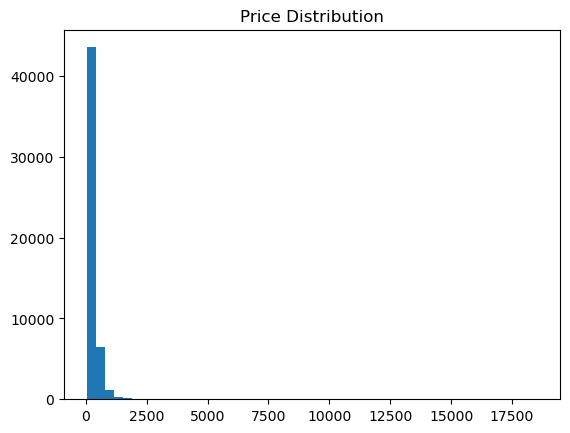

In [85]:
#Visualize the price distribution
plt.hist(df["realSum"], bins=50)
plt.title("Price Distribution")
plt.show()

In [86]:
#Percentales check
df["realSum"].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.01      71.540458
0.05      96.079488
0.10     113.155495
0.25     148.752174
0.50     211.343089
0.75     319.694287
0.90     500.880049
0.95     661.986406
0.99    1160.836332
Name: realSum, dtype: float64

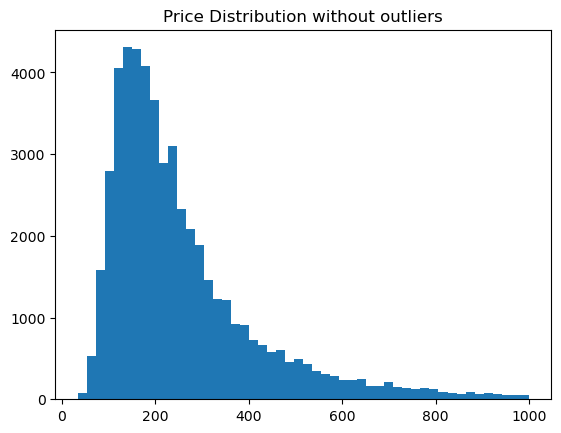

In [87]:
#Remove the outliers
df = df[df["realSum"] < 1000]
#Visualize the result
plt.hist(df["realSum"], bins=50)
plt.title("Price Distribution without outliers")
plt.show()



In [88]:
#Check the quality of the data
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique()
}).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

quality.head(30)

,dtype,missing_n,missing_pct,n_unique
day_type,object,0,0.0,2
room_shared,bool,0,0.0,2
room_private,bool,0,0.0,2
host_is_superhost,bool,0,0.0,2
multi,int64,0,0.0,2
biz,int64,0,0.0,2
room_type,object,0,0.0,3
person_capacity,float64,0,0.0,5
cleanliness_rating,float64,0,0.0,9
bedrooms,int64,0,0.0,9


In [89]:
#Check the duplicates
dup_all = df.duplicated().sum()
dup_no_price = df.drop(columns=["realSum"]).duplicated().sum()

print(f"Exact duplicate rows: {dup_all}")
print(f"Duplicate feature rows (ignoring realSum): {dup_no_price}")

Exact duplicate rows: 0
Duplicate feature rows (ignoring realSum): 0


In [90]:
#Drop the duplicates if any
#before = len(df)
#df = df.drop_duplicates().copy()
#after = len(df)
#print(f"Rows before: {before}, after: {after}, removed: {before-after}")

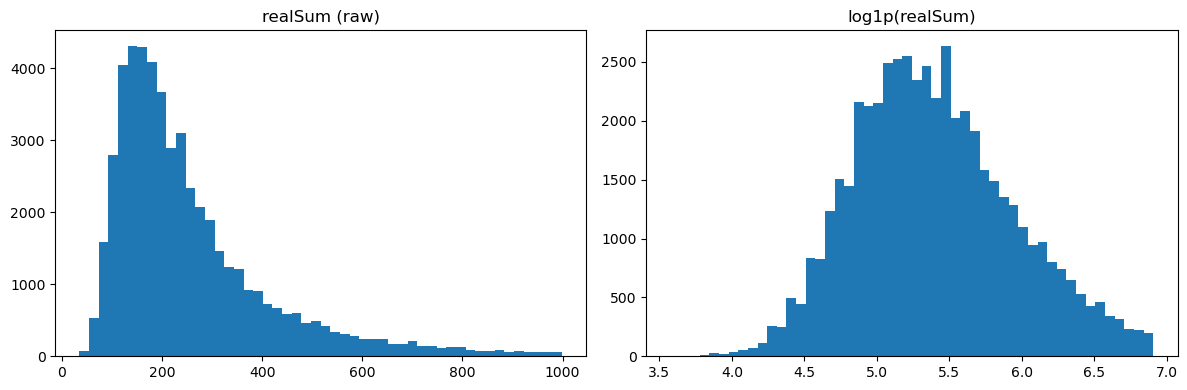

In [91]:
#Compare the original price distribution with the log-transformed version
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["realSum"], bins=50)
ax[0].set_title("realSum (raw)")

#Log-transform the price to make it more normally distributed
ax[1].hist(np.log1p(df["realSum"]), bins=50)
ax[1].set_title("log1p(realSum)")

plt.tight_layout()
plt.show()

In [92]:
#Aggregate price by city and day type
city_price = df.groupby("city")["realSum"].agg(["count", "median", "mean"]).sort_values("median", ascending=False)
day_price = df.groupby("day_type")["realSum"].agg(["count", "median", "mean"]).sort_values("median", ascending=False)

display(city_price)
display(day_price)

,count,median,mean
city,,,
amsterdam,1875,430.248635,475.286700
paris,6504,312.703887,360.294924
london,9698,256.120793,315.815674
lisbon,5760,225.375235,237.629272
vienna,3534,208.494028,230.394338
barcelona,2802,208.299393,270.176719
berlin,2467,190.006544,231.639676
rome,9004,182.591822,202.058073
budapest,4015,152.982093,172.740565


,count,median,mean
day_type,,,
weekends,25790,213.885075,261.320392
weekdays,25146,205.302358,253.032605


In [93]:
##Aggregate price by room type and capacity
room_price = df.groupby("room_type")["realSum"].agg(["count", "median", "mean"]).sort_values("median", ascending=False)
cap_price = df.groupby("person_capacity")["realSum"].agg(["count", "median", "mean"]).sort_values("person_capacity")

display(room_price)
display(cap_price)

,count,median,mean
room_type,,,
Entire home/apt,31951,243.845417,294.332957
Private room,18619,165.992565,195.791034
Shared room,366,124.479283,143.566164


,count,median,mean
person_capacity,,,
2.0,24234,184.080529,217.571323
3.0,6136,194.030904,229.446961
4.0,13673,240.282355,293.613810
5.0,2843,252.670453,306.499900
6.0,4050,322.784459,379.195054


In [105]:
#Compute correlation with the target
num_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()
corr_to_target = (
    df[num_cols]
    .corr(numeric_only=True)["realSum"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_to_target

realSum                       1.000000
attr_index_norm               0.427052
lat                           0.322413
person_capacity               0.305018
lng                          -0.299920
room_private                 -0.290079
attr_index                    0.276057
bedrooms                      0.252079
rest_index_norm               0.250666
rest_index                    0.227919
metro_dist                   -0.093047
multi                        -0.088517
biz                           0.084648
host_is_superhost            -0.075706
dist                         -0.065673
room_shared                  -0.060149
guest_satisfaction_overall   -0.027079
cleanliness_rating           -0.015884
Name: realSum, dtype: float64

In [110]:
#Display the top 3 features associated with the target
top5_feats = corr_to_target.drop(index="realSum", errors="ignore").head(3)
print("Top 3 features associated with target: ") 
print(top5_feats)

Top 3 features associated with target: 
attr_index_norm    0.427052
lat                0.322413
person_capacity    0.305018
Name: realSum, dtype: float64


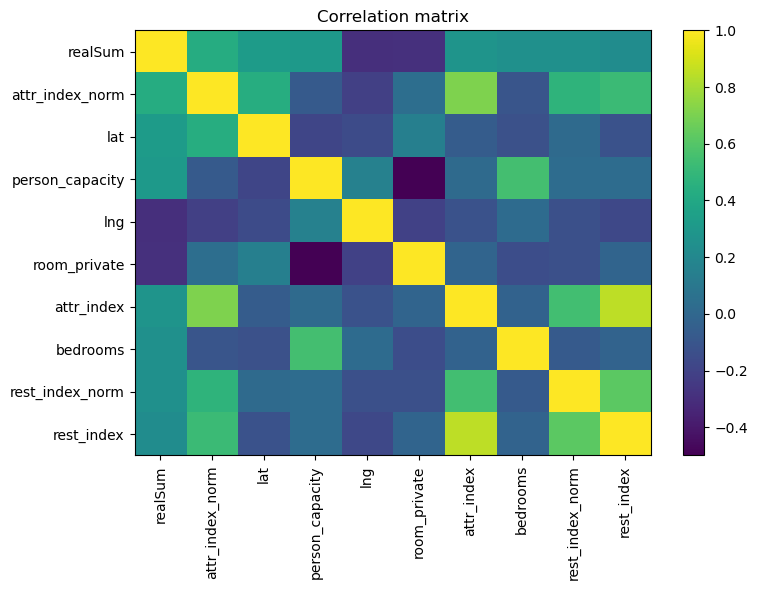

In [ ]:
#Check for multicollinearity
top_num = corr_to_target.index[:10].tolist()  # includes realSum
corr_matrix = df[top_num].corr(numeric_only=True)

#Plot the matrix
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(top_num)), top_num, rotation=90)
plt.yticks(range(len(top_num)), top_num)
plt.title("Correlation matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
#Find the most correlated features
num_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()
num_feats = [c for c in num_cols if c != "realSum"]
corr_matrix = df[num_feats].corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .query("abs_corr > 0.8")
    .sort_values("abs_corr", ascending=False)
)
high_corr_pairs

,feature_1,feature_2,abs_corr
122,attr_index,rest_index,0.851964


In [ ]:
drops = set()
keeps = set()

for _, row in high_corr_pairs.iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    c1, c2 = abs(corr_to_target[f1]), abs(corr_to_target[f2])

    # keep the one more related to target
    if c1 >= c2:
        keep, drop = f1, f2
    else:
        keep, drop = f2, f1

    keeps.add(keep)
    drops.add(drop)

# if a feature appears in both keep/drop due to chain pairs, keep wins
final_drop = sorted(drops - keeps)

print("Proposed drop list:", final_drop)
print("Number of dropped features:", len(final_drop))

Proposed drop list: ['rest_index']
Number of dropped features: 1


In [98]:
#Drop features
drop_cols = ["Unnamed: 0"] + final_drop
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + ["realSum"])
y = df["realSum"]

print("Dropped:", drop_cols)
print("X shape:", X.shape)

Dropped: ['rest_index']
X shape: (50936, 19)


In [99]:
#Build final features
drop_cols = ["Unnamed: 0", drop_feature]  # add leakage/noisy cols if needed
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols + ["realSum"])
y = df["realSum"]

print("Dropped:", drop_cols)
print("X shape:", X.shape)

Dropped: ['rest_index']
X shape: (50936, 19)


In [100]:
#Validate final feature set 
print("X missing total:", X.isna().sum().sum())
print("y missing total:", y.isna().sum())
print("Any duplicated rows in X:", X.duplicated().any())

display(X.head())

X missing total: 0
y missing total: 0
Any duplicated rows in X: False


,city,day_type,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index_norm,lng,lat
0,amsterdam,weekdays,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,6.846473,4.90569,52.41772
1,amsterdam,weekdays,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,58.342928,4.90005,52.37432
2,amsterdam,weekdays,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,6.646700,4.97512,52.36103
3,amsterdam,weekdays,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,60.973565,4.89417,52.37663
4,amsterdam,weekdays,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,56.811677,4.90051,52.37508


## Key findings 
- Final cleaned dataset contains 50936 rows and 20 before train/test split.
- Data quality is good: 0 missing values**, and artifact column "Unnamed: 0" dropped.
- Target variable "realSum" is right-skewed; we removed the outlier to reduce extreme-value impact.
- Group-level pricing differences are visible across city, room type and person capacity.
- Strongest target associations (numeric) include: "attr_index_norm", "lat"", "person_capacity". 
- Multicollinearity check (|r| > 0.8) found 1 pair; we dropped "rest_index" and kept "attr_index" based on stronger target relation and interpretability. 	
- Final feature matrix for modeling:  X (features) with 50936 features, 19 columns, target: y = realSum.
- Remaining caveat: exact semantic definitions/units of index features should be verified against original dataset documentation.

In [101]:
#Save EDA results
eda_df = X.copy()
eda_df["realSum"] = y

eda_df.to_csv("../data/processed/airbnb_eda_ready.csv", index=False)
print("Saved: ../data/processed/airbnb_eda_ready.csv", eda_df.shape)

Saved: ../data/processed/airbnb_eda_ready.csv (50936, 20)


## EDA closeout markdown

- Data quality checks completed (missing, duplicates, outliers)
- Feature selection completed (drop_cols listed)
- Multicollinearity reviewed (threshold + actions)
- Dataset ready for preprocessing/model training